In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

In [ ]:
def set_seed(seed: int):
    np.random.seed(seed)

def safe_normalize_rows(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

def trunc_noise_sampler(bound_noise=1.0, scale=0.3):
    a = -bound_noise / scale
    b =  bound_noise / scale
    dist = stats.truncnorm(a=a, b=b, loc=0.0, scale=scale)
    return dist

def get_epsilon(d, T):
    return ((d * np.log(max(T, 2))) ** 2 / T) ** (1/3)

def get_alpha(T, B_noise):
    return 1 / (T + 2 * (T**2) * (3 + (B_noise + 1) * (T**(1/3))))

def get_mu(d, epsilon, B_theta, B_y, B_x, T, alpha):
    sqrt_tmp = np.sqrt(d * np.log((1 + T * (B_x ** 2)) / alpha))
    return epsilon / (B_theta + B_y * sqrt_tmp)

def norm_invA(x, A):
    return np.sqrt(np.dot(x, np.linalg.solve(A, x)))

def revenue_from_accept(price, accept):
    return price * accept

In [ ]:
@dataclass
class EnvConfig:
    name: str
    d: int = 8
    T: int = 5000
    n_contexts: int = 50
    bound_x: float = 1.0
    bound_theta: float = 1.0
    bound_noise: float = 1.0
    noise_scale: float = 0.3
    drift_scale: float = 0.25
    cold_start_fraction: float = 0.1
    semantic_topics: int = 5

class DynamicPricingEnv:
    def __init__(self, cfg: EnvConfig, seed: int = 0):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)
        self.noise_dist = trunc_noise_sampler(cfg.bound_noise, cfg.noise_scale)

        # Base theta
        theta = self.rng.normal(size=cfg.d)
        theta = theta / np.linalg.norm(theta)
        self.theta0 = cfg.bound_theta * theta

        # For nonlinear / nonstationary
        self.theta1 = self.theta0.copy()
        drift_dir = self.rng.normal(size=cfg.d)
        drift_dir = drift_dir / np.linalg.norm(drift_dir)
        self.theta2 = cfg.bound_theta * (
            (1 - cfg.drift_scale) * self.theta0 + cfg.drift_scale * drift_dir
        )
        self.theta2 = cfg.bound_theta * self.theta2 / np.linalg.norm(self.theta2)

        # Semantic prototypes for E4/E5
        self.topic_centers = safe_normalize_rows(
            self.rng.normal(size=(cfg.semantic_topics, cfg.d))
        )

    def sample_context(self, t: int):
        cfg = self.cfg

        if cfg.name == "E1_linear":
            x = self.rng.uniform(-1, 1, size=cfg.d)

        elif cfg.name == "E2_nonlinear":
            x = self.rng.uniform(-1, 1, size=cfg.d)

        elif cfg.name == "E3_nonstationary":
            x = self.rng.uniform(-1, 1, size=cfg.d)

        elif cfg.name == "E4_semantic":
            topic = self.rng.integers(0, cfg.semantic_topics)
            x = self.topic_centers[topic] + 0.15 * self.rng.normal(size=cfg.d)

        elif cfg.name == "E5_coldstart_llmprior":
            topic = self.rng.integers(0, cfg.semantic_topics)
            x = self.topic_centers[topic] + 0.15 * self.rng.normal(size=cfg.d)

            # cold-start portion has more unseen-style contexts
            if t < int(cfg.cold_start_fraction * cfg.T):
                x = x + 0.25 * self.rng.normal(size=cfg.d)

        else:
            raise ValueError(f"Unknown environment {cfg.name}")

        x = x / max(np.linalg.norm(x), 1e-12)
        return x

    def latent_value_mean(self, x: np.ndarray, t: int):
        cfg = self.cfg

        if cfg.name == "E1_linear":
            return float(np.dot(self.theta0, x))

        elif cfg.name == "E2_nonlinear":
            linear = np.dot(self.theta0, x)
            nonlinear = 0.4 * np.sin(2.5 * linear) + 0.25 * (x[0] ** 2 - x[1] * x[2])
            return float(linear + nonlinear)

        elif cfg.name == "E3_nonstationary":
            theta_t = self.theta1 if t < cfg.T // 2 else self.theta2
            return float(np.dot(theta_t, x))

        elif cfg.name == "E4_semantic":
            linear = np.dot(self.theta0, x)
            semantic_bump = 0.35 * np.tanh(1.8 * x[0] - 1.2 * x[1] + 0.8 * x[2])
            return float(linear + semantic_bump)

        elif cfg.name == "E5_coldstart_llmprior":
            linear = np.dot(self.theta0, x)
            semantic_bump = 0.25 * np.tanh(1.2 * x[0] + 0.9 * x[3])
            return float(linear + semantic_bump)

        raise ValueError("Unknown environment.")

    def step(self, price: float, t: int):
        x = self.sample_context(t)
        u = self.latent_value_mean(x, t)
        xi = float(self.noise_dist.rvs())
        y = u + xi
        accept = int(price <= y)
        reward = price * accept
        return {
            "x": x,
            "u": u,
            "xi": xi,
            "y": y,
            "price": price,
            "accept": accept,
            "reward": reward
        }

    def oracle_price(self, x: np.ndarray, t: int, price_grid: np.ndarray):
        u = self.latent_value_mean(x, t)
        cdf = self.noise_dist.cdf(price_grid - u)
        rev = price_grid * (1 - cdf)
        idx = np.argmax(rev)
        return price_grid[idx], rev[idx]

In [ ]:
class BasePricingAlgo:
    def __init__(self, name: str, d: int, B_x: float, B_theta: float, B_noise: float):
        self.name = name
        self.d = d
        self.B_x = B_x
        self.B_theta = B_theta
        self.B_noise = B_noise
        self.B_y = 1.0

    def select_price(self, x: np.ndarray, t: int) -> float:
        raise NotImplementedError

    def update(self, x: np.ndarray, price: float, accept: int, t: int):
        raise NotImplementedError

In [ ]:
class VAPEAlgo(BasePricingAlgo):
    def __init__(self, d, T, L_xi=1.0, B_x=1.0, B_theta=1.0, B_noise=1.0):
        super().__init__("VAPE", d, B_x, B_theta, B_noise)
        self.T = T
        self.L_xi = L_xi
        self.epsilon = 0.5 * get_epsilon(d, T)
        self.alpha = get_alpha(T, B_noise)
        self.mu = 0.5* get_mu(d, self.epsilon, B_theta, self.B_y, B_x, T, self.alpha)

        self.theta_hat = np.zeros(d)
        self.V = np.eye(d)
        self.sum_ox = np.zeros(d)

        self.K = math.ceil((B_noise + 1) / self.epsilon)
        self.N = np.ones(2 * self.K + 1)
        self.D_hat = np.zeros(2 * self.K + 1)

    def update_theta_V(self, x, o):
        self.V = self.V + np.outer(x, x)
        self.sum_ox = self.sum_ox + (o - 0.5) * x
        self.theta_hat = 2 * self.B_y * np.linalg.solve(self.V, self.sum_ox)

    def precheck_actions(self, g_hat):
        arms = []
        for k in range(2 * self.K + 1):
            est = g_hat + (k - self.K) * self.epsilon
            if 0 < est < self.B_y:
                arms.append(k)
        if len(arms) == 0:
            arms = [self.K]
        return arms

    def compute_bounds(self, g_hat):
        ks = np.arange(-self.K, self.K + 1)
        est = g_hat + ks * self.epsilon
        width = np.sqrt(2 * np.log(1 / self.alpha) / self.N) + 2 * self.L_xi * self.epsilon
        ucb = est * np.clip(self.D_hat + width, 0.0, 1.0)
        lcb = est * np.clip(self.D_hat - width, 0.0, 1.0)
        return ucb, lcb

    def select_arm(self, ucb, lcb, prechecked):
        max_lcb = np.max(lcb[prechecked])
        valid = [k for k in prechecked if ucb[k] >= max_lcb]
        if len(valid) == 0:
            valid = prechecked
        return min(valid, key=lambda k: self.N[k])

    def select_price(self, x, t):
        norm = norm_invA(x, self.V)

        if norm > self.mu:
            return np.random.uniform(0.0, self.B_y)

        g_hat = float(np.dot(x, self.theta_hat))
        ucb, lcb = self.compute_bounds(g_hat)
        prechecked = self.precheck_actions(g_hat)
        k = self.select_arm(ucb, lcb, prechecked)
        price = g_hat + (k - self.K) * self.epsilon
        return float(np.clip(price, 0.0, self.B_y))

    def update(self, x, price, accept, t):
        norm = norm_invA(x, self.V)
        if norm > self.mu:
            self.update_theta_V(x, accept)
        else:
            g_hat = float(np.dot(x, self.theta_hat))
            k = int(np.round((price - g_hat) / self.epsilon)) + self.K
            k = int(np.clip(k, 0, 2 * self.K))
            self.D_hat[k] = (self.N[k] * self.D_hat[k] + accept) / (self.N[k] + 1)
            self.N[k] += 1

In [ ]:
class CAPEAlgo(BasePricingAlgo):
    def __init__(self, d, T, B_x=1.0, B_theta=1.0, B_noise=1.0,
                 n_price_grid=81, bandwidth=None, prior_strength=1.0,
                 theta_prior_mean=None):
        super().__init__("CAPE", d, B_x, B_theta, B_noise)
        self.T = T
        self.price_grid = np.linspace(0.0, self.B_y, n_price_grid)
        self.bandwidth =0.1
        self.prior_strength = prior_strength

        self.theta_hat = np.zeros(d) if theta_prior_mean is None else theta_prior_mean.copy()
        self.V = np.eye(d) * prior_strength
        self.b = self.V @ self.theta_hat

        self.history_x = []
        self.history_p = []
        self.history_o = []

    def update_theta(self, x, o):
        # same idea as VAPE-style linear update
        self.V = self.V + np.outer(x, x)
        self.b = self.b + 2 * self.B_y * (o - 0.5) * x
        self.theta_hat = np.linalg.solve(self.V, self.b)

    def kernel(self, z):
        out = np.zeros_like(z, dtype=float)
        mask = np.abs(z) <= 1
        out[mask] = 0.75 * (1 - z[mask] ** 2)
        return out

    def estimate_monotone_survival(self, x):
        if len(self.history_p) < 20:
            # bootstrap warm-start
            surv = np.clip(1 - self.price_grid / max(self.B_y, 1e-8), 0, 1)
            return surv

        g_hat = float(np.dot(x, self.theta_hat))
        increments = np.array(self.history_p) - np.array(self.history_x) @ self.theta_hat
        accepts = np.array(self.history_o)

        surv_est = []
        for inc in (self.price_grid - g_hat):
            z = (increments - inc) / self.bandwidth
            w = self.kernel(z)
            denom = np.sum(w) + 1e-8
            num = np.sum(w * accepts)
            surv_est.append(num / denom)

        surv_est = np.array(surv_est)

        # monotone decreasing projection
        ir = IsotonicRegression(increasing=False, out_of_bounds='clip')
        surv_iso = ir.fit_transform(self.price_grid, surv_est)
        surv_iso = np.clip(surv_iso, 1e-4, 1.0)
        return surv_iso

    def select_price(self, x, t):
        if t < max(25, self.d * 5):
            return np.random.uniform(0.0, self.B_y)

        surv = self.estimate_monotone_survival(x)

        # approximate posterior sampling on demand
        pseudo_counts = 10.0
        alpha = 1 + pseudo_counts * surv
        beta = 1 + pseudo_counts * (1 - surv)
        sampled_surv = np.random.beta(alpha, beta)

        sampled_rev = self.price_grid * sampled_surv
        return float(self.price_grid[np.argmax(sampled_rev)])

    def update(self, x, price, accept, t):
        self.update_theta(x, accept)
        self.history_x.append(x.copy())
        self.history_p.append(float(price))
        self.history_o.append(int(accept))

In [ ]:
class ExploreThenUCBAlgo(BasePricingAlgo):
    def __init__(self, d, T, B_x=1.0, B_theta=1.0, B_noise=1.0,
                 explore_frac=0.2, n_price_grid=61, theta_prior_mean=None):
        super().__init__("ExUCB", d, B_x, B_theta, B_noise)
        self.T = T
        self.explore_T = max(int(explore_frac * T), 50)
        self.price_grid = np.linspace(0.0, self.B_y, n_price_grid)

        self.X = []
        self.P = []
        self.O = []

        self.theta_hat = np.zeros(d) if theta_prior_mean is None else theta_prior_mean.copy()
        self.lr = LinearRegression(fit_intercept=False)

    def fit_theta(self):
        if len(self.X) < self.d:
            return
        X = np.array(self.X)
        O = np.array(self.O)
        target = self.B_y * O
        self.lr.fit(X, target)
        self.theta_hat = self.lr.coef_

    def estimate_acceptance_curve(self, x):
        if len(self.P) < 20:
            return np.clip(1 - self.price_grid / max(self.B_y, 1e-8), 0, 1)

        g_hat = float(np.dot(x, self.theta_hat))
        increments = np.array(self.P) - np.array(self.X) @ self.theta_hat
        accepts = np.array(self.O)

        band = max(0.08, len(self.P) ** (-1/5))
        acc = []
        for inc in self.price_grid - g_hat:
            z = (increments - inc) / band
            w = np.exp(-0.5 * z ** 2)
            denom = np.sum(w) + 1e-8
            acc.append(np.sum(w * accepts) / denom)

        acc = np.array(acc)
        ir = IsotonicRegression(increasing=False, out_of_bounds='clip')
        acc = ir.fit_transform(self.price_grid, acc)
        return np.clip(acc, 1e-4, 1.0)

    def select_price(self, x, t):
        if t < self.explore_T:
            return np.random.uniform(0.0, self.B_y)

        self.fit_theta()
        acc = self.estimate_acceptance_curve(x)

        n_eff = max(len(self.P), 1)
        bonus = np.sqrt(2 * np.log(max(t + 2, 3)) / n_eff)
        ucb = self.price_grid * np.clip(acc + bonus, 0, 1)
        return float(self.price_grid[np.argmax(ucb)])

    def update(self, x, price, accept, t):
        self.X.append(x.copy())
        self.P.append(float(price))
        self.O.append(int(accept))

In [ ]:
def build_llm_prior(env: DynamicPricingEnv, strength: float = 0.75):
    # synthetic "LLM prior": average topic center direction
    prior = env.topic_centers.mean(axis=0)
    prior = prior / max(np.linalg.norm(prior), 1e-12)
    return strength * env.cfg.bound_theta * prior

In [ ]:
def run_single(env_cfg: EnvConfig, algo_name: str, seed: int = 0):
    set_seed(seed)
    env = DynamicPricingEnv(env_cfg, seed=seed)

    theta_prior = None
    if env_cfg.name == "E5_coldstart_llmprior":
        theta_prior = build_llm_prior(env, strength=0.75)

    if algo_name == "VAPE":
        algo = VAPEAlgo(
            d=env_cfg.d, T=env_cfg.T,
            L_xi=1.0,
            B_x=env_cfg.bound_x,
            B_theta=env_cfg.bound_theta,
            B_noise=env_cfg.bound_noise
        )
    elif algo_name == "CAPE":
        algo = CAPEAlgo(
            d=env_cfg.d, T=env_cfg.T,
            B_x=env_cfg.bound_x,
            B_theta=env_cfg.bound_theta,
            B_noise=env_cfg.bound_noise,
            theta_prior_mean=theta_prior
        )
    elif algo_name == "ExUCB":
        algo = ExploreThenUCBAlgo(
            d=env_cfg.d, T=env_cfg.T,
            B_x=env_cfg.bound_x,
            B_theta=env_cfg.bound_theta,
            B_noise=env_cfg.bound_noise,
            theta_prior_mean=theta_prior
        )
    else:
        raise ValueError(f"Unknown algo {algo_name}")

    price_grid = np.linspace(0.0, algo.B_y, 201)

    rewards = np.zeros(env_cfg.T)
    oracle_rewards = np.zeros(env_cfg.T)
    prices = np.zeros(env_cfg.T)
    accepts = np.zeros(env_cfg.T)
    valuation_means = np.zeros(env_cfg.T)

    for t in range(env_cfg.T):
        x = env.sample_context(t)
        p = algo.select_price(x, t)

        u = env.latent_value_mean(x, t)
        xi = float(env.noise_dist.rvs())
        y = u + xi
        accept = int(p <= y)
        reward = p * accept

        _, oracle_reward = env.oracle_price(x, t, price_grid)

        algo.update(x, p, accept, t)

        rewards[t] = reward
        oracle_rewards[t] = oracle_reward
        prices[t] = p
        accepts[t] = accept
        valuation_means[t] = u

    regret = np.cumsum(oracle_rewards - rewards)

    return {
        "algo": algo_name,
        "env": env_cfg.name,
        "rewards": rewards,
        "oracle_rewards": oracle_rewards,
        "cum_regret": regret,
        "prices": prices,
        "accepts": accepts,
        "valuation_means": valuation_means,
    }

In [ ]:
def run_benchmark(env_cfgs: List[EnvConfig], algos=("VAPE", "CAPE", "ExUCB"), n_seeds=10):
    results = {}

    for env_cfg in env_cfgs:
        results[env_cfg.name] = {}
        print(f"\nEnvironment: {env_cfg.name}")

        for algo in algos:
            print(f"  Running {algo} ...")
            runs = []
            for seed in range(n_seeds):
                out = run_single(env_cfg, algo, seed=seed)
                runs.append(out)
            results[env_cfg.name][algo] = runs

    return results

In [ ]:
def summarize_runs(runs):
    regrets = np.array([r["cum_regret"] for r in runs])
    rewards = np.array([np.cumsum(r["rewards"]) for r in runs])
    accepts = np.array([r["accepts"] for r in runs])

    return {
        "regret_mean": regrets.mean(axis=0),
        "regret_std": regrets.std(axis=0),
        "reward_mean": rewards.mean(axis=0),
        "reward_std": rewards.std(axis=0),
        "accept_mean": accepts.mean(axis=0),
        "accept_std": accepts.std(axis=0),
    }

def plot_env_results(results, env_name):
    env_res = results[env_name]
    T = len(next(iter(env_res.values()))[0]["cum_regret"])
    xs = np.arange(1, T + 1)

    plt.figure(figsize=(7, 4))
    for algo, runs in env_res.items():
        s = summarize_runs(runs)
        plt.plot(xs, s["regret_mean"], label=algo)
        plt.fill_between(xs,
                         s["regret_mean"] - s["regret_std"],
                         s["regret_mean"] + s["regret_std"],
                         alpha=0.2)
    plt.title(f"Cumulative Regret: {env_name}")
    plt.xlabel("t")
    plt.ylabel("Cumulative regret")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    for algo, runs in env_res.items():
        s = summarize_runs(runs)
        plt.plot(xs, s["reward_mean"], label=algo)
        plt.fill_between(xs,
                         s["reward_mean"] - s["reward_std"],
                         s["reward_mean"] + s["reward_std"],
                         alpha=0.2)
    plt.title(f"Cumulative Reward: {env_name}")
    plt.xlabel("t")
    plt.ylabel("Cumulative reward")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    for algo, runs in env_res.items():
        s = summarize_runs(runs)
        plt.scatter(xs, s["accept_mean"], label=algo, alpha=0.5)
    plt.title(f"Acceptance Rate: {env_name}")
    plt.xlabel("t")
    plt.ylabel("Acceptance")
    plt.legend()
    plt.show()

In [ ]:
env_cfgs = [
    EnvConfig(name="E1_linear", T=4000, d=8),
    EnvConfig(name="E2_nonlinear", T=4000, d=8),
    EnvConfig(name="E3_nonstationary", T=4000, d=8),
    EnvConfig(name="E4_semantic", T=4000, d=16, semantic_topics=6),
    EnvConfig(name="E5_coldstart_llmprior", T=4000, d=16, semantic_topics=6, cold_start_fraction=0.15),
]

In [ ]:
results = run_benchmark(env_cfgs, algos=("VAPE", "CAPE", "ExUCB"), n_seeds=10)


Environment: E1_linear
  Running VAPE ...
  Running CAPE ...
  Running ExUCB ...

Environment: E2_nonlinear
  Running VAPE ...
  Running CAPE ...
  Running ExUCB ...

Environment: E3_nonstationary
  Running VAPE ...
  Running CAPE ...
  Running ExUCB ...

Environment: E4_semantic
  Running VAPE ...
  Running CAPE ...
  Running ExUCB ...

Environment: E5_coldstart_llmprior
  Running VAPE ...
  Running CAPE ...
  Running ExUCB ...


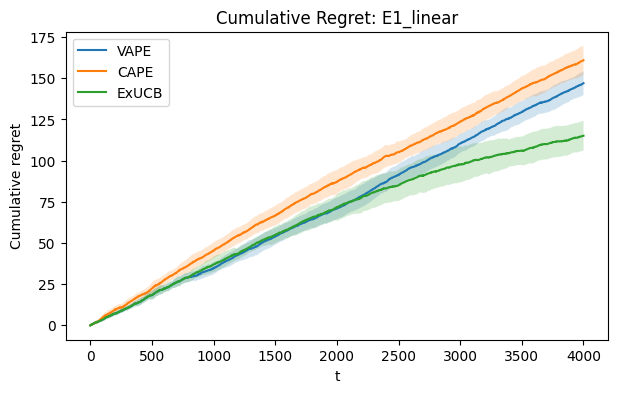

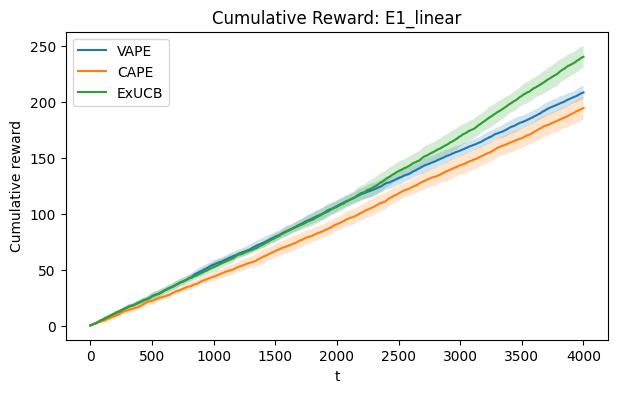

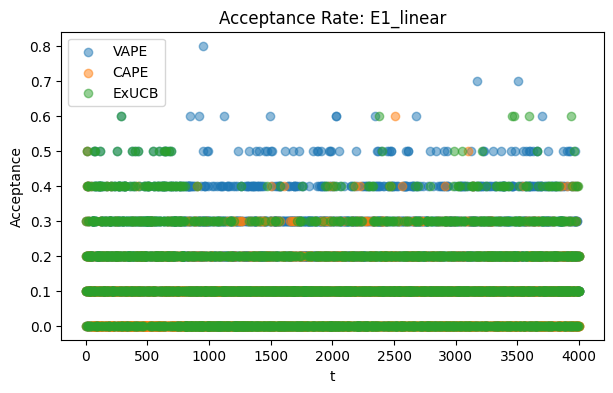

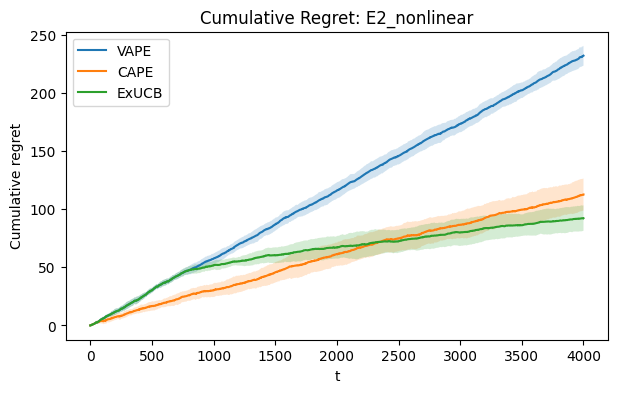

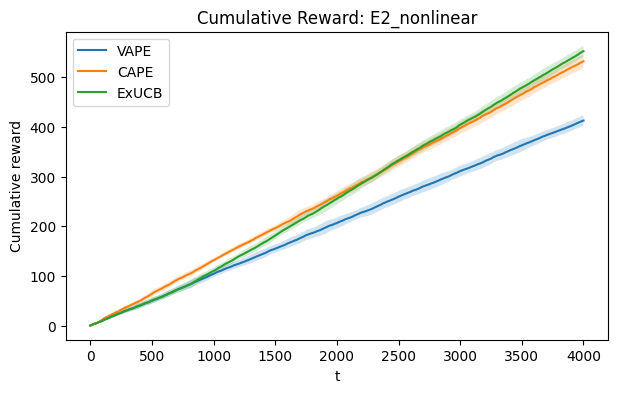

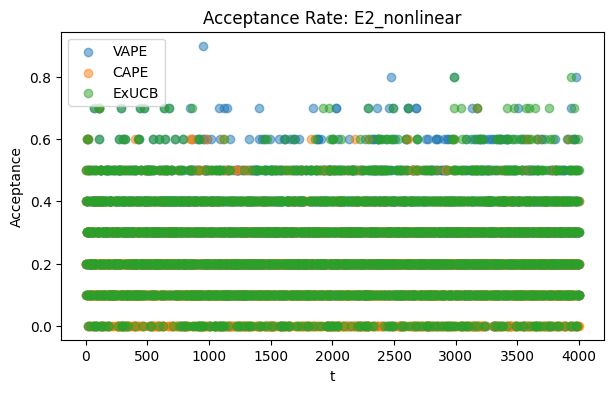

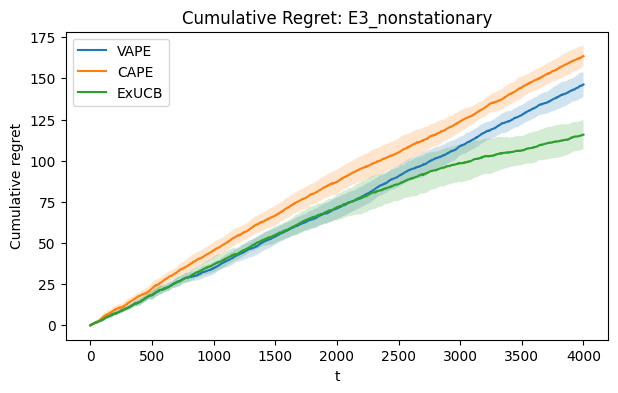

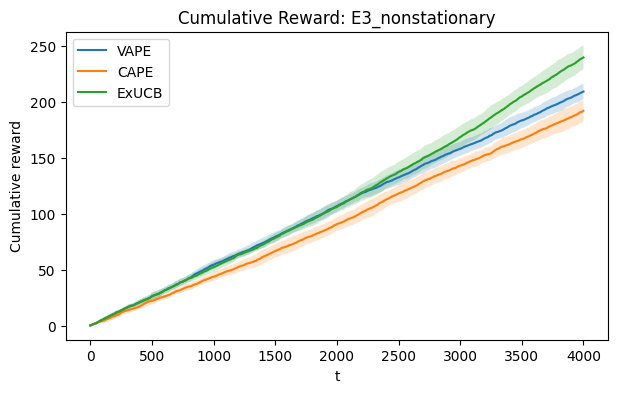

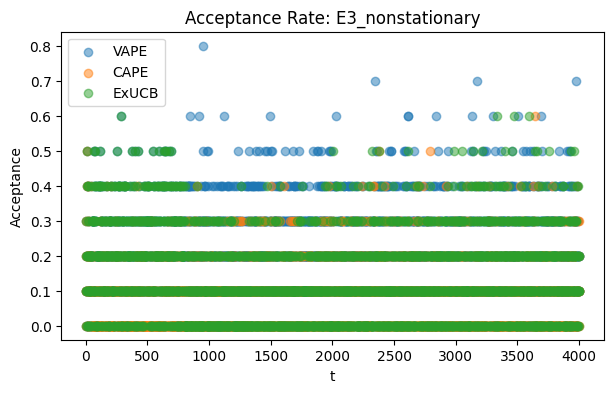

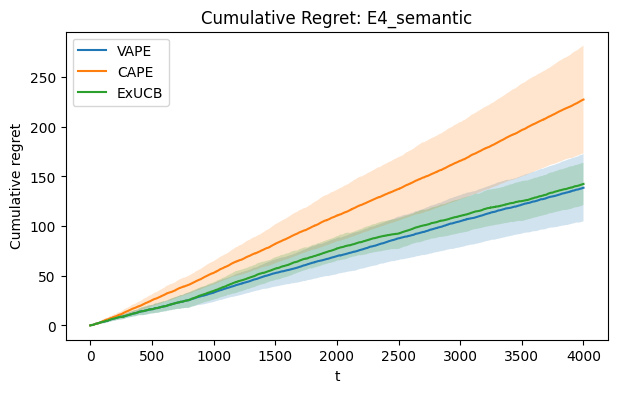

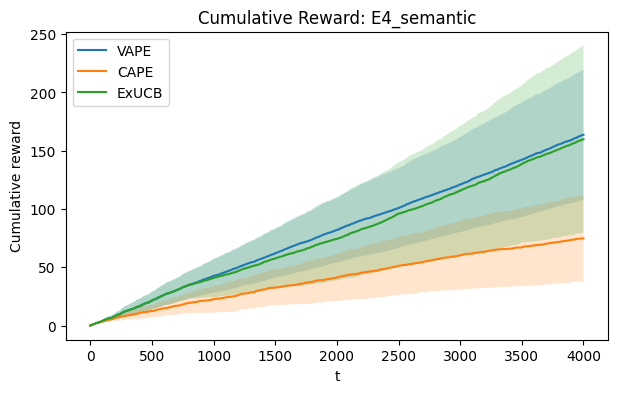

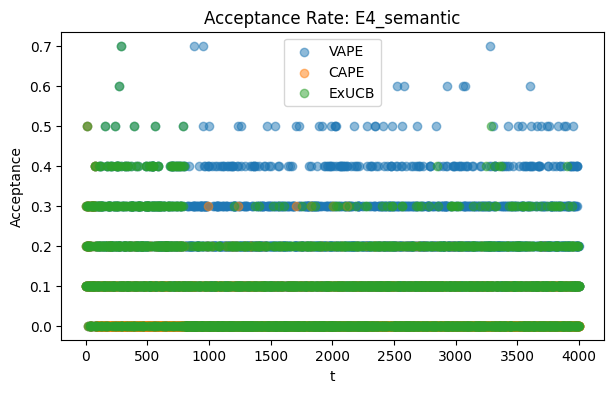

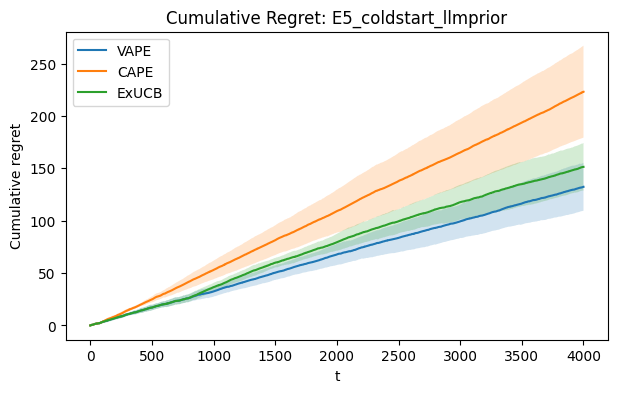

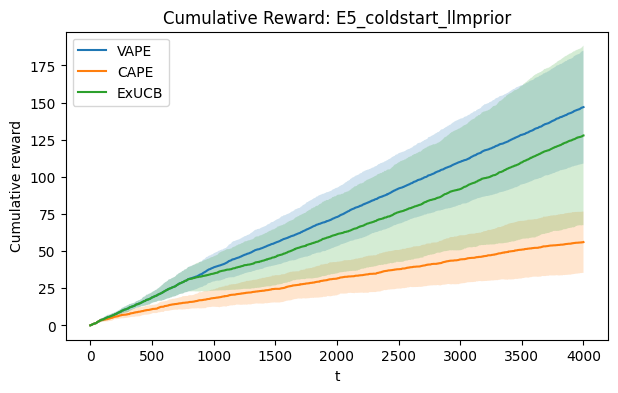

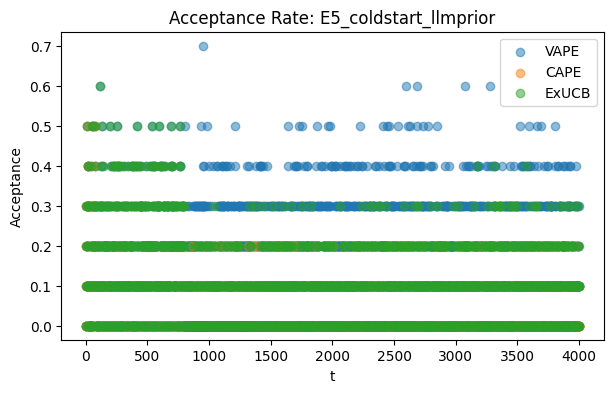

In [ ]:
for env_name in results:
    plot_env_results(results, env_name)